In [1]:
from pathlib import Path
import pandas as pd
from process_log import parse_log_file
from visualize_CSV_signal import visualize_signal
from get_timestamps import get_response_timestamps, get_event_timestamps
from assign_timestamps import assign_stim_timestamps

In [2]:
data_dir = Path("data/Natalia")

output_folder = data_dir / "dataframe"
output_folder.mkdir(exist_ok=True)

output_path = output_folder / "df_full.csv"

files_events = [
    data_dir / "CSV" / "events_1.csv",
    data_dir / "CSV" / "events_2.csv",
    data_dir / "CSV" / "events_3.csv",
]

In [11]:
# Parsing log into a csv

log_files = [
    data_dir / "Task" / "Go_Off_1.log",
    data_dir / "Task" / "Go_Off_2.log",
    data_dir / "Task" / "Go_Off_3.log",
]

dfs = []

for file in log_files:
    df = parse_log_file(file)
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df["trial"] = range(1, len(df) + 1)

df.to_csv(output_path, index=False)

print(f"Saved full dataset: {output_path}")

Saved full dataset: data\Natalia\dataframe\df_full.csv


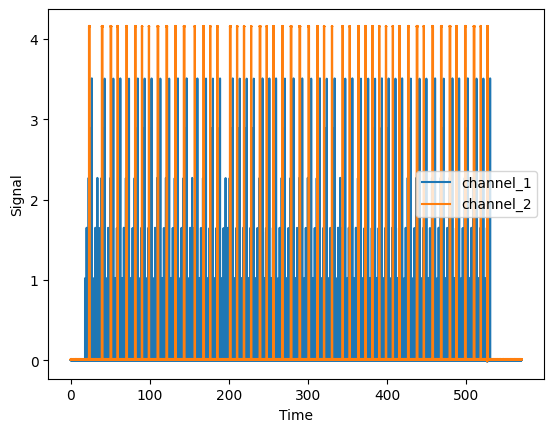

Mean dt: 0.0005


In [14]:
# Visualize signal from csv
filepath = data_dir / "CSV" / "events_1.csv"
visualize_signal(filepath)


In [12]:
# Get response timestamps
df = pd.read_csv(output_path)

result = get_response_timestamps(files_events)
df["response_ts"] = result["peak_time"].values

df.to_csv(output_path, index=False)

data\Natalia\CSV\events_1.csv 50
data\Natalia\CSV\events_2.csv 50
data\Natalia\CSV\events_3.csv 50


In [8]:
#Check total appearanceof stim1 and stim2
df = pd.read_csv(output_path)

# sum each column
stim1_total = df["stim1_count"].sum()
stim2_total = df["stim2_count"].sum()

print("Stim1 total:", stim1_total)
print("Stim2 total:", stim2_total)

Stim1 total: 159
Stim2 total: 81


In [3]:
# Get event timestamps
df = pd.read_csv(output_path)
result = get_event_timestamps(files_events)

df["trial_start_ts"] = result["trial_start"]
df["feedback1_ts"] = result["feedback1"]
df["feedback2_ts"] = result["feedback2"]

df.to_csv(output_path, index=False)

df_ts = assign_stim_timestamps(df, result)
df_ts.to_csv(output_path, index=False)

data\Natalia\CSV\events_1.csv | trial_start: 50
data\Natalia\CSV\events_1.csv | stim1: 54
data\Natalia\CSV\events_1.csv | stim2: 29
data\Natalia\CSV\events_1.csv | feedback1: 50
data\Natalia\CSV\events_1.csv | feedback2: 50
data\Natalia\CSV\events_2.csv | trial_start: 50
data\Natalia\CSV\events_2.csv | stim1: 54
data\Natalia\CSV\events_2.csv | stim2: 28
data\Natalia\CSV\events_2.csv | feedback1: 50
data\Natalia\CSV\events_2.csv | feedback2: 50
data\Natalia\CSV\events_3.csv | trial_start: 50
data\Natalia\CSV\events_3.csv | stim1: 51
data\Natalia\CSV\events_3.csv | stim2: 24
data\Natalia\CSV\events_3.csv | feedback1: 50
data\Natalia\CSV\events_3.csv | feedback2: 50

TOTAL COUNTS
trial_start: 150
feedback1: 150
feedback2: 150
stim1: 159
stim2: 81
